# Coordinates: location and coverage audit

Longitude and latitude are two columns, but they represent one location. Auditing or cleaning either column independently would break that meaning.

This notebook records the coordinate and regional evidence needed before preprocessing or modelling:

1. How many training and test rows have usable coordinates?
2. How is missing location encoded?
3. How many valid coordinate pairs are repeated?
4. Are repeated locations duplicate records, and do their training labels agree?
5. Is regional coverage broadly balanced, and does the label mix vary by region?

## 1. Load and validate the source data

Both feature sets are needed because coordinate handling must be reproducible at prediction time. Labels are joined only to the training rows.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

source_directory = str(Path("../src").resolve())
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

from source_data_validation import (
    validate_aligned_ids,
    validate_label_frame,
    validate_raw_feature_schema,
)

data_directory = Path("../data")
training_features = pd.read_csv(data_directory / "TrainingSetValues.csv")
training_labels = pd.read_csv(data_directory / "TrainingSetLabels.csv")
test_features = pd.read_csv(data_directory / "TestSetValues.csv")

validate_raw_feature_schema(training_features)
validate_raw_feature_schema(test_features)
validate_label_frame(training_labels)
validate_aligned_ids(training_features, training_labels)

training_data = training_features.merge(
    training_labels,
    on="id",
    validate="one_to_one",
)

## 2. Treat coordinate validity as one condition

The broad bounds below contain Tanzania and reject the dataset's `(0, approximately 0)` sentinel. The `&` operators combine four pandas boolean Series row by row: this is the DataFrame equivalent of applying one compound predicate to every record.

In [2]:
coordinate_columns = ["longitude", "latitude"]
tanzania_bounds = {
    "west": 28,
    "east": 42,
    "south": -13,
    "north": 0,
}

training_has_usable_coordinates = (
    training_data["longitude"].between(tanzania_bounds["west"], tanzania_bounds["east"])
    & training_data["latitude"].between(tanzania_bounds["south"], tanzania_bounds["north"])
)
test_has_usable_coordinates = (
    test_features["longitude"].between(tanzania_bounds["west"], tanzania_bounds["east"])
    & test_features["latitude"].between(tanzania_bounds["south"], tanzania_bounds["north"])
)

training_valid = training_data.loc[training_has_usable_coordinates].copy()
test_valid = test_features.loc[test_has_usable_coordinates].copy()

coordinate_summary = pd.DataFrame({
    "rows": [len(training_data), len(test_features)],
    "usable coordinate rows": [len(training_valid), len(test_valid)],
    "missing or out-of-bounds rows": [
        int((~training_has_usable_coordinates).sum()),
        int((~test_has_usable_coordinates).sum()),
    ],
    "usable percentage": [
        training_has_usable_coordinates.mean() * 100,
        test_has_usable_coordinates.mean() * 100,
    ],
    "unique usable coordinate pairs": [
        training_valid[coordinate_columns].drop_duplicates().shape[0],
        test_valid[coordinate_columns].drop_duplicates().shape[0],
    ],
}, index=["training", "test"])
coordinate_summary["usable percentage"] = coordinate_summary["usable percentage"].round(2)

training_invalid_values = (
    training_data.loc[~training_has_usable_coordinates, coordinate_columns]
    .value_counts(dropna=False)
    .rename("training rows")
    .to_frame()
)
test_invalid_values = (
    test_features.loc[~test_has_usable_coordinates, coordinate_columns]
    .value_counts(dropna=False)
    .rename("test rows")
    .to_frame()
)

display(coordinate_summary)
display(training_invalid_values.join(test_invalid_values, how="outer").fillna(0).astype(int))

,rows,usable coordinate rows,missing or out-of-bounds rows,usable percentage,unique usable coordinate pairs
training,59400,57588,1812,96.95,57519
test,14850,14393,457,96.92,14389


,,training rows,test rows
longitude,latitude,,
0.0,-2.000000e-08,1812,457


### Observation

The training data has 57,588 usable coordinate rows and 1,812 missing-location rows. The test data has 14,393 usable rows and 457 missing-location rows. Every rejected row uses the same sentinel: longitude `0.0` and latitude `-2e-08`.

This is missing data encoded as plausible numeric values, not a real location near Tanzania. It should become an explicit availability indicator before the sentinel is replaced with missing values.

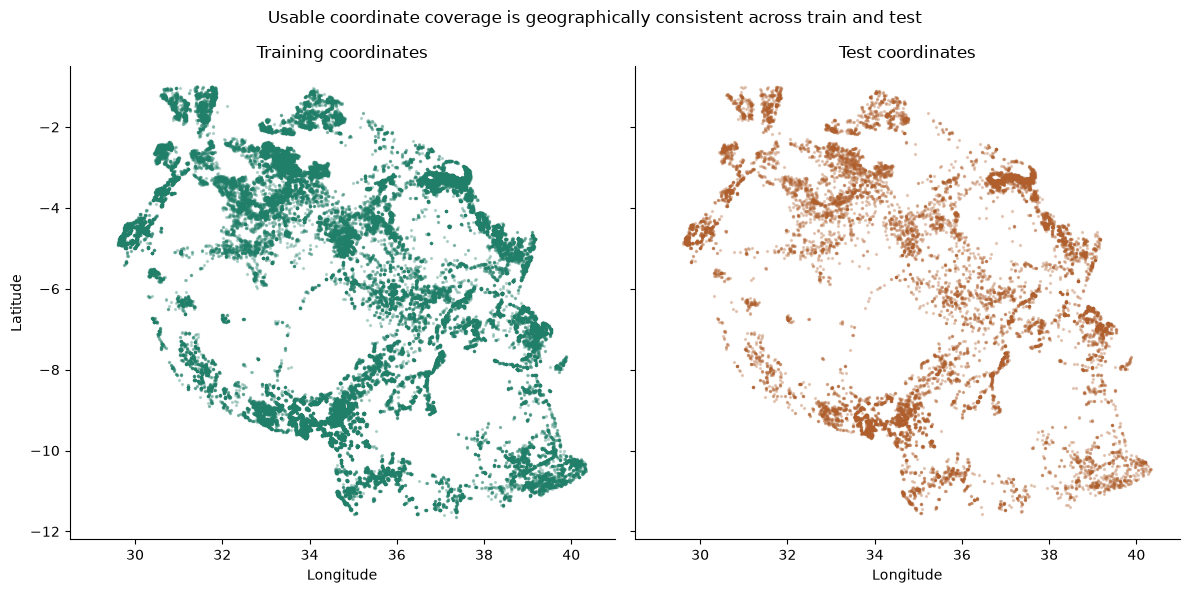

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
for ax, frame, title, colour in [
    (axes[0], training_valid, "Training coordinates", "#207f69"),
    (axes[1], test_valid, "Test coordinates", "#b05f2c"),
]:
    ax.scatter(frame["longitude"], frame["latitude"], s=2, alpha=0.25, color=colour)
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_xlim(28.5, 41)
    ax.set_ylim(-12.2, -0.5)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Latitude")
fig.suptitle("Usable coordinate coverage is geographically consistent across train and test")
fig.tight_layout()
plt.show()

### Observation

**OMG that's a skull!**

Once seen, it cannot be unseen: the usable-coordinate cloud looks uncannily like a right-facing human skull. This is pareidolia rather than a data insight, but it is a memorable reminder that even a plain scatter plot can expose geographic structure immediately.

<p><img src="images/right-facing-skull.png" alt="Right-facing lateral human skull used as a visual comparison" width="420" style="transform: scaleX(-1);"></p>

*Look, see?! [CC0 reference image by GDJ via ClipSafari](https://www.clipsafari.com/clips/o241359-realistic-human-skull-profile-view), mirrored here to face right.*

## 3. Find repeated valid locations

A repeated coordinate is not automatically a duplicate record. First count coordinate groups; then compare the remaining columns within each two-row group.

In [4]:
training_coordinate_group_sizes = training_valid.groupby(coordinate_columns).size()
test_coordinate_group_sizes = test_valid.groupby(coordinate_columns).size()

training_repeated_rows = training_valid.loc[
    training_valid.duplicated(coordinate_columns, keep=False)
].copy()
test_repeated_rows = test_valid.loc[
    test_valid.duplicated(coordinate_columns, keep=False)
].copy()

repeated_coordinate_summary = pd.DataFrame({
    "repeated coordinate groups": [
        int(training_coordinate_group_sizes.gt(1).sum()),
        int(test_coordinate_group_sizes.gt(1).sum()),
    ],
    "rows in repeated groups": [len(training_repeated_rows), len(test_repeated_rows)],
    "largest group": [
        int(training_coordinate_group_sizes.max()),
        int(test_coordinate_group_sizes.max()),
    ],
}, index=["training", "test"])

repeated_coordinate_summary

,repeated coordinate groups,rows in repeated groups,largest group
training,69,138,2
test,4,8,2


In [5]:
def compare_two_row_coordinate_groups(frame, columns_to_compare):
    comparisons = []
    for coordinates, group in frame.groupby(coordinate_columns, sort=True):
        if len(group) != 2:
            raise ValueError(f"Expected a two-row coordinate group at {coordinates!r}.")

        left = group.iloc[0]
        right = group.iloc[1]
        differing_columns = []
        for column in columns_to_compare:
            both_missing = pd.isna(left[column]) and pd.isna(right[column])
            if not both_missing and left[column] != right[column]:
                differing_columns.append(column)

        comparisons.append({
            "longitude": coordinates[0],
            "latitude": coordinates[1],
            "left id": int(left["id"]),
            "right id": int(right["id"]),
            "differing column count": len(differing_columns),
            "differing columns": tuple(differing_columns),
        })

    return pd.DataFrame(comparisons)

training_feature_columns_without_id = [
    column for column in training_features.columns if column != "id"
]
training_pair_comparison = compare_two_row_coordinate_groups(
    training_repeated_rows,
    training_feature_columns_without_id,
)
training_pair_comparison["difference pattern"] = training_pair_comparison[
    "differing columns"
].map(lambda columns: ", ".join(columns) or "(none)")

training_difference_patterns = (
    training_pair_comparison["difference pattern"]
    .value_counts()
    .rename("coordinate pairs")
    .to_frame()
)
training_exact_feature_duplicates = training_pair_comparison.loc[
    training_pair_comparison["differing column count"].eq(0),
    ["longitude", "latitude", "left id", "right id"],
]
training_labels_per_coordinate = training_repeated_rows.groupby(coordinate_columns)[
    "status_group"
].nunique()

display(training_difference_patterns)
display(training_exact_feature_duplicates)
print(
    "Repeated training locations with conflicting labels:",
    int(training_labels_per_coordinate.gt(1).sum()),
)

,coordinate pairs
difference pattern,
"funder, installer, permit",24
date_recorded,22
"gps_height, population, construction_year",13
"amount_tsh, gps_height, population, construction_year",8
(none),1
"gps_height, ward, population, construction_year",1


,longitude,latitude,left id,right id
0,31.61953,-1.793342,29553,18713


Repeated training locations with conflicting labels: 0


### Training observation

There are 69 repeated valid coordinate pairs, accounting for 138 rows. Only one pair is a whole-feature duplicate after excluding `id`: IDs `29553` and `18713` at `(31.61952953, -1.793342)`.

The other pairs differ in plausible survey or asset fields: 22 differ only by `date_recorded`; 24 differ by `funder`, `installer` and `permit`; the remainder mainly differ in `gps_height`, `population`, `construction_year`, and occasionally `amount_tsh` or `ward`. All 69 pairs have matching labels.

In [6]:
test_feature_columns_without_id = [
    column for column in test_features.columns if column != "id"
]
test_pair_comparison = compare_two_row_coordinate_groups(
    test_repeated_rows,
    test_feature_columns_without_id,
)
test_pair_comparison["difference pattern"] = test_pair_comparison[
    "differing columns"
].map(lambda columns: ", ".join(columns) or "(none)")

test_exact_duplicate_rows = test_features.loc[
    test_features.duplicated(test_feature_columns_without_id, keep=False),
    ["id", "longitude", "latitude"],
]

display(
    test_pair_comparison[[
        "longitude",
        "latitude",
        "left id",
        "right id",
        "difference pattern",
    ]]
)
display(test_exact_duplicate_rows)

,longitude,latitude,left id,right id,difference pattern
0,32.920579,-2.474560,8015,3000,"gps_height, population, construction_year"
1,37.260069,-7.105919,25609,31110,date_recorded
2,37.302281,-7.170666,17640,9490,date_recorded
3,39.080573,-6.990042,23564,30889,"funder, installer, permit"


,id,longitude,latitude
1014,49317,0.0,-2.000000e-08
14676,44766,0.0,-2.000000e-08


### Test observation

The test set has four repeated valid coordinate pairs and none is a whole-feature duplicate. Two differ only by `date_recorded`; one differs by `gps_height`, `population` and `construction_year`; one differs by `funder`, `installer` and `permit`.

The only exact test duplicate after excluding `id` is IDs `49317` and `44766`, and both use the missing-coordinate sentinel.

## 4. Compare labels at repeated training locations

Because both rows in every repeated pair have the same label, the row distribution is also the pair distribution multiplied by two. Compare it with all usable-coordinate training rows to see whether repeated locations look representative.

,repeated-location rows,repeated-location percentage,all valid-coordinate percentage
status_group,,,
functional,62,44.93,54.51
functional needs repair,8,5.80,6.83
non functional,68,49.28,38.67


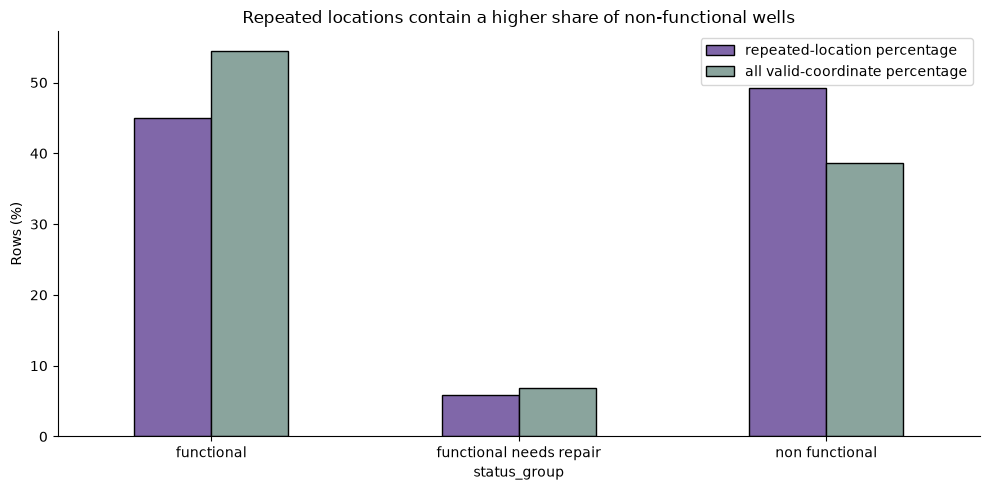

In [7]:
label_order = [
    "functional",
    "functional needs repair",
    "non functional",
]
duplicate_label_counts = (
    training_repeated_rows["status_group"].value_counts().reindex(label_order)
)
valid_label_counts = training_valid["status_group"].value_counts().reindex(label_order)

duplicate_label_comparison = pd.DataFrame({
    "repeated-location rows": duplicate_label_counts,
    "repeated-location percentage": duplicate_label_counts / len(training_repeated_rows) * 100,
    "all valid-coordinate percentage": valid_label_counts / len(training_valid) * 100,
})
display(duplicate_label_comparison.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
plot_values = duplicate_label_comparison[[
    "repeated-location percentage",
    "all valid-coordinate percentage",
]]
plot_values.plot.bar(ax=ax, color=["#8067a9", "#8aa49d"], edgecolor="black")
ax.set_title("Repeated locations contain a higher share of non-functional wells")
ax.set_xlabel("status_group")
ax.set_ylabel("Rows (%)")
ax.tick_params(axis="x", rotation=0)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## 5. Put coordinate coverage in regional context

`region` has no missing values and only 21 values, making it a useful geographic summary alongside the continuous coordinate pair. Dataset share measures coverage; row percentages measure the label mix within each region.

status_group,rows,dataset share (%),functional (%),functional needs repair (%),non functional (%)
region,,,,,
Iringa,5294,9.19,78.22,2.32,19.46
Mbeya,4639,8.06,49.99,10.86,39.15
Kilimanjaro,4379,7.60,60.29,7.35,32.36
Morogoro,4006,6.96,52.90,7.49,39.62
Shinyanga,3977,6.91,57.56,7.42,35.03
Arusha,3350,5.82,68.48,5.22,26.30
Kagera,3316,5.76,52.08,9.17,38.75
Kigoma,2816,4.89,48.40,21.41,30.18
Ruvuma,2640,4.58,56.06,6.21,37.73


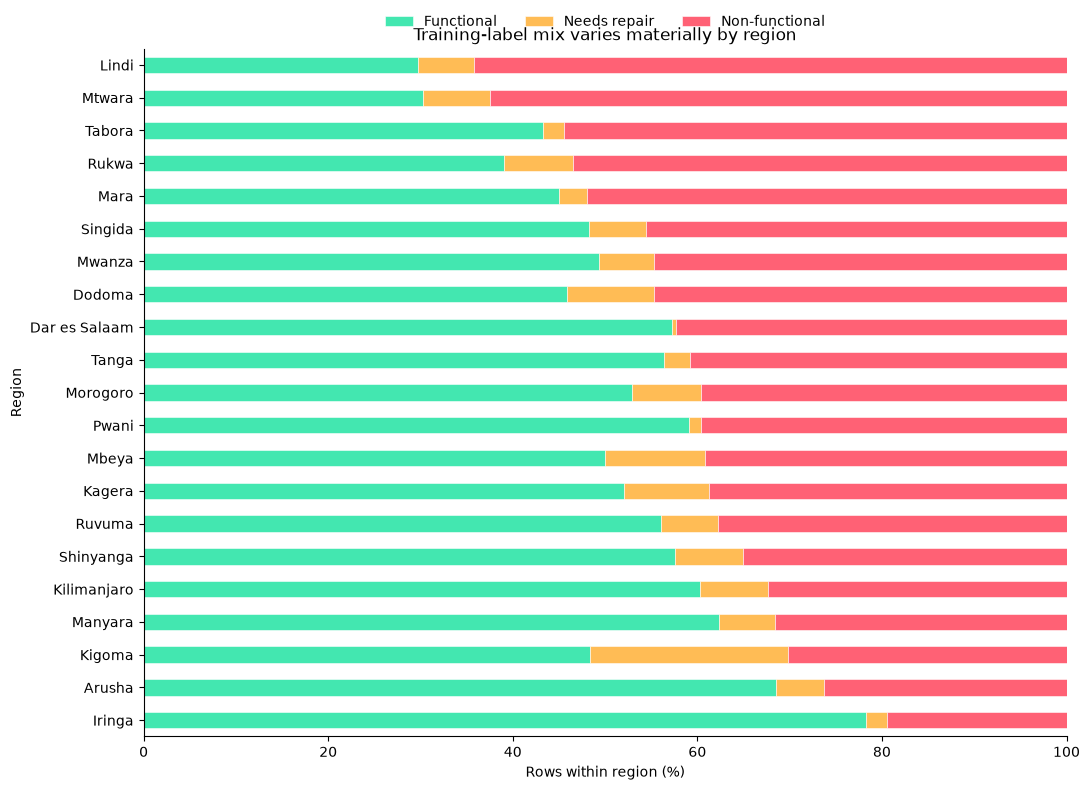

In [8]:
regional_label_counts = (
    pd.crosstab(training_valid["region"], training_valid["status_group"])
    .reindex(columns=label_order, fill_value=0)
)
regional_summary = regional_label_counts.copy()
regional_summary["rows"] = regional_label_counts.sum(axis=1)
regional_summary["dataset share (%)"] = regional_summary["rows"] / len(training_valid) * 100
for label in label_order:
    regional_summary[f"{label} (%)"] = (
        regional_summary[label] / regional_summary["rows"] * 100
    )

regional_summary = regional_summary.sort_values("rows", ascending=False)
regional_display_columns = [
    "rows",
    "dataset share (%)",
    "functional (%)",
    "functional needs repair (%)",
    "non functional (%)",
]
display(regional_summary[regional_display_columns].round(2))

regional_label_mix = regional_summary[[f"{label} (%)" for label in label_order]]
regional_label_mix.columns = ["Functional", "Needs repair", "Non-functional"]
regional_label_mix = regional_label_mix.sort_values("Non-functional")

fig, ax = plt.subplots(figsize=(11, 8))
regional_label_mix.plot.barh(
    stacked=True,
    ax=ax,
    color=["#43e7b0", "#ffbc55", "#ff6175"],
    edgecolor="white",
    linewidth=0.4,
)
ax.set_title("Training-label mix varies materially by region")
ax.set_xlabel("Rows within region (%)")
ax.set_ylabel("Region")
ax.set_xlim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=3, frameon=False)
fig.tight_layout()
plt.show()

### Regional observation

Coverage is uneven but not dominated by one region. Iringa is largest at 9.19% of usable-coordinate rows; Dar es Salaam is smallest at 1.40%; the five largest regions contain 38.71%.

The label mix varies much more than coverage. Lindi is 64.2% non-functional and Mtwara is 62.4%, while Iringa is 78.2% functional and only 19.5% non-functional. Kigoma has the highest `functional needs repair` share at 21.4%. Region is therefore likely to be predictive, but this is association rather than an explanation of why a well fails.

## 6. Findings and decisions

| Finding | Evidence | Consequence |
| --- | --- | --- |
| Coordinates are one compound concept | Longitude and latitude jointly determine location | Validate, transform and mark missingness as a pair |
| Missing location uses a numeric sentinel | 1,812 training and 457 test rows use `(0, -2e-08)` | Add a coordinate-availability feature, then replace both sentinel values with missing values |
| Valid repeated locations are uncommon | 69 training pairs and 4 test pairs | Repetition is not a broad data-quality failure |
| Repeated locations are usually not duplicate rows | Only one valid training pair is otherwise identical; no valid test pair is | Do not drop rows merely because coordinates match |
| Repeated training locations have consistent labels | Zero label conflicts across 69 pairs | Keep the rows, but keep each exact-coordinate group in one split partition to avoid direct location leakage |
| Repeated locations skew non-functional | 49.3% versus 38.7% among all valid-coordinate rows | Treat repeated-location behaviour as potentially systematic, although it affects only 138 rows |
| Geographic coverage and outcomes vary by region | Region share ranges from 1.4% to 9.2%; non-functional share ranges from 19.5% to 64.2% | Retain region and evaluate model errors by region |

Decisions for preprocessing and splitting:

1. Treat `longitude` and `latitude` as a coupled location feature, not two unrelated numbers.
2. Create `coordinates_available` before changing the sentinel pair to missing values.
3. Do not impute longitude and latitude independently; any later imputation must preserve a plausible location.
4. Do not deduplicate by coordinate pair. Retain the differing records and group exact coordinate pairs into the same train or validation partition.
5. Retain `region` as a categorical feature and inspect regional validation errors, especially in Lindi, Mtwara, Iringa and Kigoma.
6. Keep the interactive map as the exploratory view; keep this notebook as the reproducible evidence and decision record.